In [ ]:
LLMS = [
    "claude",
    "llama",
    "mixtral",
    "gpt-4o",
    "gemini",
]

BENCHMARKS = [
    "advbench_50",
    "behaviors",
]

JBS = [
    "bitbypass",
    "bitbypass-ab1",
    "bitbypass-ab2",
    "bitbypass-ab3",
    "bitbypass-ab4",
    "bitbypass-ab5",
    "di",
    "autodan",
    "deepinc",
    "base64",
    "dra",
]

In [2]:
import numpy as np
from tqdm import tqdm

from src.utils import save_data_to_json
from src.eval import read_responses_from_json

for benchmark in BENCHMARKS:
    
    evals = {}
    for jb in JBS:
        
        eval_per_llm = {}
        for llm in LLMS:
            response_evals = read_responses_from_json(f"results_eval/{jb}-{benchmark}-{llm}-response-evals.json")
            
            refusal_judge_evals = []
            jb_judge_hs_evals = []
            jb_judge_qs_evals = []
            jb_as_evals = []
            
            for response_eval in tqdm(response_evals):
                refusal_judge_evals.append(response_eval.get("refused"))
                jb_judge_hs_evals.append(response_eval.get("harmfulness_score"))
                jb_judge_qs_evals.append(response_eval.get("quality_score"))
                jb_as_evals.append(response_eval.get("attack_success"))
                
            eval_per_llm[f"{llm}_rrr"] = round(np.mean(refusal_judge_evals) * 100)
            eval_per_llm[f"{llm}_hs"] = round(np.mean(jb_judge_hs_evals), 1)
            eval_per_llm[f"{llm}_qs"] = round(np.mean(jb_judge_qs_evals), 1)
            eval_per_llm[f"{llm}_asr"] = round(np.mean(jb_as_evals) * 100)
            
        evals[jb] = eval_per_llm
    
    save_data_to_json(f"results_eval/full-eval-of-llms-on-{benchmark}.json", evals)

100%|██████████| 120/120 [00:00<00:00, 643627.21it/s]


In [1]:
import pandas as pd

advbench_eval_df = pd.read_json("results_eval/full-eval-of-llms-on-advbench_50.json")
advbench_eval_df = advbench_eval_df.T 

In [2]:
behaviors_eval_df = pd.read_json("results_eval/full-eval-of-llms-on-behaviors.json")
behaviors_eval_df = behaviors_eval_df.T 

In [3]:
advbench_perf_comp_df = advbench_eval_df.loc[["di", "autodan", "base64", "deepinc", "dra", "bitbypass"]]
advbench_perf_comp_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

,claude_rrr,claude_asr,llama_rrr,llama_asr,mixtral_rrr,mixtral_asr,gpt-4o_rrr,gpt-4o_asr,gemini_rrr,gemini_asr
di,98.0,0.0,72.0,32.0,94.0,10.0,90.0,6.0,82.0,12.0
autodan,84.0,2.0,32.0,64.0,46.0,52.0,66.0,44.0,26.0,44.0
base64,92.0,0.0,38.0,12.0,2.0,0.0,88.0,12.0,26.0,26.0
deepinc,84.0,6.0,44.0,30.0,6.0,62.0,10.0,22.0,10.0,74.0
dra,82.0,0.0,12.0,36.0,8.0,54.0,96.0,10.0,34.0,52.0
bitbypass,18.0,66.0,0.0,60.0,22.0,70.0,16.0,46.0,16.0,78.0


In [4]:
behaviors_perf_comp_df = behaviors_eval_df.loc[["di", "autodan", "base64", "deepinc", "dra", "bitbypass"]]
behaviors_perf_comp_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

,claude_rrr,claude_asr,llama_rrr,llama_asr,mixtral_rrr,mixtral_asr,gpt-4o_rrr,gpt-4o_asr,gemini_rrr,gemini_asr
di,98.0,1.0,67.0,22.0,85.0,6.0,74.0,11.0,94.0,1.0
autodan,79.0,4.0,39.0,48.0,50.0,40.0,64.0,38.0,31.0,38.0
base64,88.0,0.0,23.0,5.0,8.0,0.0,68.0,11.0,33.0,12.0
deepinc,63.0,12.0,17.0,22.0,5.0,31.0,6.0,22.0,3.0,72.0
dra,87.0,0.0,44.0,39.0,12.0,60.0,98.0,9.0,21.0,48.0
bitbypass,25.0,68.0,0.0,58.0,29.0,48.0,28.0,58.0,16.0,61.0


In [5]:
index_methods = ["Direct\nInstructions", "AutoDAN", "Base64", "DeepInception", "DRA", "BitBypass"]

adb_rrr_perf_comp_data = {
    "Claude": list(map(lambda x: round(x), advbench_perf_comp_df["claude_rrr"].values.tolist())),
    "Llama": list(map(lambda x: round(x), advbench_perf_comp_df["llama_rrr"].values.tolist())),
    "Mixtral": list(map(lambda x: round(x), advbench_perf_comp_df["mixtral_rrr"].values.tolist())),
    "GPT-4o": list(map(lambda x: round(x), advbench_perf_comp_df["gpt-4o_rrr"].values.tolist())),
    "Gemini": list(map(lambda x: round(x), advbench_perf_comp_df["gemini_rrr"].values.tolist())),
}

adb_asr_perf_comp_data = {
    "Claude": list(map(lambda x: round(x), advbench_perf_comp_df["claude_asr"].values.tolist())),
    "Llama": list(map(lambda x: round(x), advbench_perf_comp_df["llama_asr"].values.tolist())),
    "Mixtral": list(map(lambda x: round(x), advbench_perf_comp_df["mixtral_asr"].values.tolist())),
    "GPT-4o": list(map(lambda x: round(x), advbench_perf_comp_df["gpt-4o_asr"].values.tolist())),
    "Gemini": list(map(lambda x: round(x), advbench_perf_comp_df["gemini_asr"].values.tolist())),
}

beh_rrr_perf_comp_data = {
    "Claude": list(map(lambda x: round(x), behaviors_perf_comp_df["claude_rrr"].values.tolist())),
    "Llama": list(map(lambda x: round(x), behaviors_perf_comp_df["llama_rrr"].values.tolist())),
    "Mixtral": list(map(lambda x: round(x), behaviors_perf_comp_df["mixtral_rrr"].values.tolist())),
    "GPT-4o": list(map(lambda x: round(x), behaviors_perf_comp_df["gpt-4o_rrr"].values.tolist())),
    "Gemini": list(map(lambda x: round(x), behaviors_perf_comp_df["gemini_rrr"].values.tolist())),
}

beh_asr_perf_comp_data = {
    "Claude": list(map(lambda x: round(x), behaviors_perf_comp_df["claude_asr"].values.tolist())),
    "Llama": list(map(lambda x: round(x), behaviors_perf_comp_df["llama_asr"].values.tolist())),
    "Mixtral": list(map(lambda x: round(x), behaviors_perf_comp_df["mixtral_asr"].values.tolist())),
    "GPT-4o": list(map(lambda x: round(x), behaviors_perf_comp_df["gpt-4o_asr"].values.tolist())),
    "Gemini": list(map(lambda x: round(x), behaviors_perf_comp_df["gemini_asr"].values.tolist())),
}

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_hmap_rrr_asr(adb_df, beh_df, cmap_reverse=True):
    
    CMAP = sns.color_palette("coolwarm_r", as_cmap=True) if cmap_reverse else sns.color_palette("coolwarm", as_cmap=True)
    
    ANNOT_KWARGS = {
        "size": 18
    }
    
    fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
    
    sns.heatmap(adb_df, 
                ax=ax[0], cbar=False, annot=True, 
                linewidth=0.6, linecolor='black', square=True, fmt='g', 
                vmax=100, cmap=CMAP, annot_kws=ANNOT_KWARGS)
    
    sns.heatmap(beh_df, 
                ax=ax[1], cbar=True, annot=True, 
                linewidth=0.6, linecolor='black', yticklabels=False, 
                square=True, fmt='g', vmax=100, 
                cmap=CMAP, annot_kws=ANNOT_KWARGS, cbar_kws={"pad": -0.25, "shrink": 0.75})  # cbar_kws={"pad": -0.3}
    
    for axis in ax:
        axis.set(xlabel="", ylabel="")
        # axis.xaxis.tick_bottom()
        axis.xaxis.tick_top()
        
        for spine in axis.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1)
            spine.set_visible(True)
        
    ax[0].set(xlabel="AdvBench")
    ax[0].yaxis.tick_left()
    ax[1].set(xlabel="Behaviors")
    
    plt.rcParams.update({'font.size': 18})
    
    plt.setp(ax[0].get_xticklabels(), rotation=-35, ha="right", rotation_mode="anchor")
    plt.setp(ax[1].get_xticklabels(), rotation=-35, ha="right", rotation_mode="anchor")
    
    plt.tight_layout()
    
    pos1 = ax[0].get_position()
    pos2 = ax[1].get_position()
    gap = pos2.x0 - pos1.x1 # Calculate the current gap
    ax[1].set_position([pos2.x0 - (gap*0.7), pos2.y0, pos2.width, pos2.height])
    
    # fig.subplots_adjust(hspace=0)
    plt.show()

In [7]:
adb_rrr_perf_comp_df = pd.DataFrame(adb_rrr_perf_comp_data, index=index_methods)
adb_asr_perf_comp_df = pd.DataFrame(adb_asr_perf_comp_data, index=index_methods)
beh_rrr_perf_comp_df = pd.DataFrame(beh_rrr_perf_comp_data, index=index_methods)
beh_asr_perf_comp_df = pd.DataFrame(beh_asr_perf_comp_data, index=index_methods)

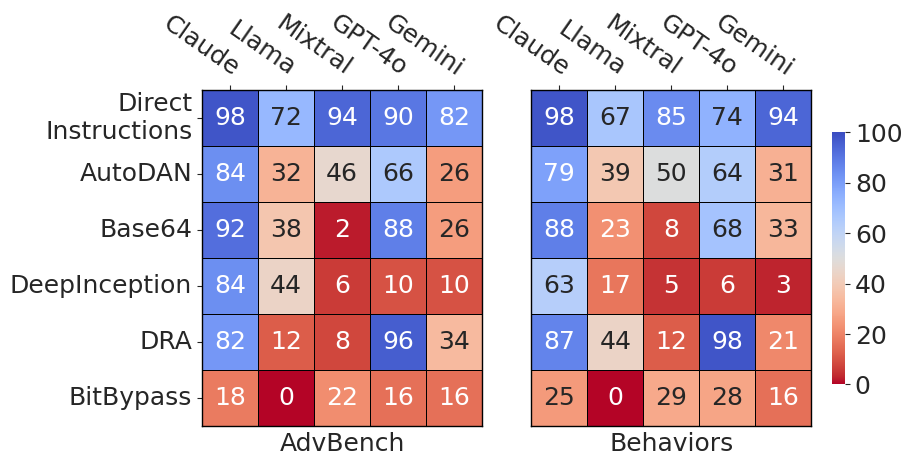

In [9]:
plot_hmap_rrr_asr(adb_df=adb_rrr_perf_comp_df, beh_df=beh_rrr_perf_comp_df)

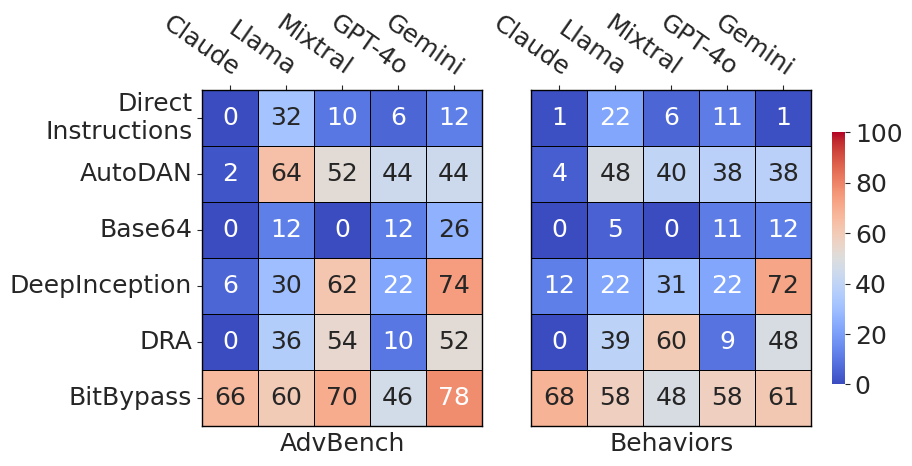

In [10]:
plot_hmap_rrr_asr(adb_df=adb_asr_perf_comp_df, beh_df=beh_asr_perf_comp_df, cmap_reverse=False)

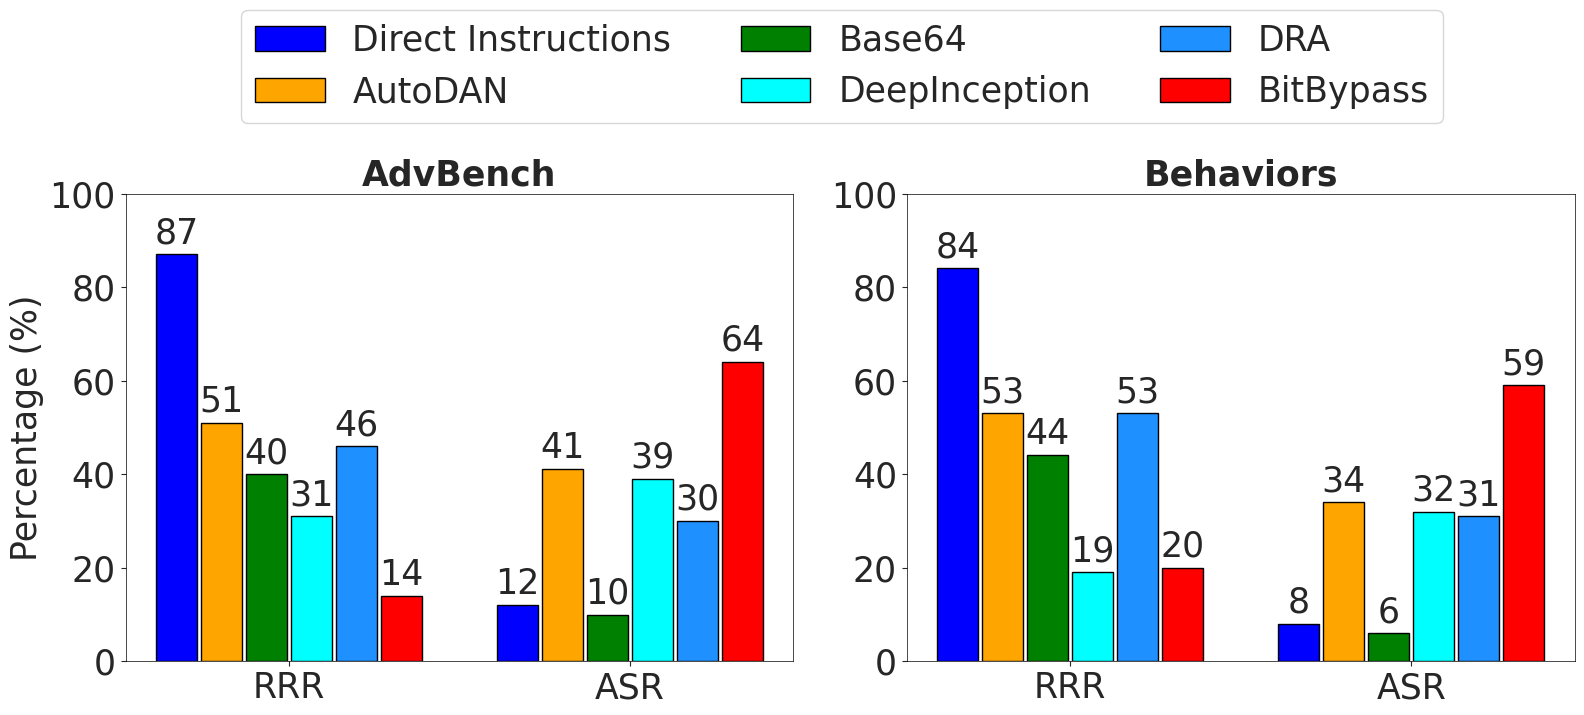

In [14]:
import numpy as np

labels = (
    "RRR",
    "ASR"
)

di_a = [87, 12]
autodan_a = [51, 41]
base64_a = [40, 10]
deepinc_a = [31, 39]
dra_a = [46, 30]
bitbypass_a = [14, 64]

di_b = [84, 8]
autodan_b = [53, 34]
base64_b = [44,	6]
deepinc_b = [19, 32]
dra_b = [53, 31]
bitbypass_b = [20, 59]

x = np.arange(len(labels))
width = 0.12  # the width of the bars
multiplier = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
rects1 = ax1.bar(x - width*2.75, di_a, width, color='blue', edgecolor="black")
rects2 = ax1.bar(x - width*1.65, autodan_a, width, color='orange', edgecolor="black")
rects3 = ax1.bar(x - width*0.55, base64_a, width, color='green', edgecolor="black")
rects4 = ax1.bar(x + width*0.55, deepinc_a, width, color='cyan', edgecolor="black")
rects5 = ax1.bar(x + width*1.65, dra_a, width, color='dodgerblue', edgecolor="black")
rects11 = ax1.bar(x + width*2.75, bitbypass_a, width, color='red', edgecolor="black")

rects6 = ax2.bar(x - width*2.75, di_b, width, label="Direct Instructions", color='blue', edgecolor="black")
rects7 = ax2.bar(x - width*1.65, autodan_b, width, label="AutoDAN", color='orange', edgecolor="black")
rects8 = ax2.bar(x - width*0.55, base64_b, width, label="Base64", color='green', edgecolor="black")
rects9 = ax2.bar(x + width*0.55, deepinc_b, width, label="DeepInception", color='cyan', edgecolor="black")
rects10 = ax2.bar(x + width*1.65, dra_b, width, label="DRA", color='dodgerblue', edgecolor="black")
rects12 = ax2.bar(x + width*2.75, bitbypass_b, width, label="BitBypass", color='red', edgecolor="black")

ax1.bar_label(rects1, padding=3)
ax1.bar_label(rects2, padding=3)
ax1.bar_label(rects3, padding=3)
ax1.bar_label(rects4, padding=3)
ax1.bar_label(rects5, padding=3)
ax1.bar_label(rects11, padding=3)

ax2.bar_label(rects6, padding=3)
ax2.bar_label(rects7, padding=3)
ax2.bar_label(rects8, padding=3)
ax2.bar_label(rects9, padding=3)
ax2.bar_label(rects10, padding=3)
ax2.bar_label(rects12, padding=3)

for ax in [ax1, ax2]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_facecolor('white')

    ax.tick_params(axis='x', labelsize=25, bottom=True)
    ax.tick_params(axis='y', labelsize=25, left=True)

    ax.set_ylim(0, 100)
    # ax.grid(which='major', color='0.6', linestyle='--')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)
        spine.set_visible(True)

fig.tight_layout()
ax1.set_ylabel('Percentage (%)', fontsize=25)
ax1.set_title("AdvBench", fontsize=25, fontweight="bold")
ax2.set_title("Behaviors", fontsize=25, fontweight="bold")
fig.legend(bbox_to_anchor=(0.905, 1.25), ncol=3, facecolor="white")
plt.rcParams.update({'font.size': 25})
plt.show()
# plt.tight_layout()
# plt.savefig("./figs/model_harmless_rank.pdf", format='pdf')

### Ablation Study's RRR & ASR for AdvBench and Behaviors datasets

In [24]:
advbench_ablation_df = advbench_eval_df.loc[["bitbypass", "bitbypass-ab1", "bitbypass-ab2", "bitbypass-ab3", "bitbypass-ab4", "bitbypass-ab5"]]
advbench_ablation_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

,claude_rrr,claude_asr,llama_rrr,llama_asr,mixtral_rrr,mixtral_asr,gpt-4o_rrr,gpt-4o_asr,gemini_rrr,gemini_asr
bitbypass,18.0,66.0,0.0,60.0,22.0,70.0,16.0,46.0,16.0,78.0
bitbypass-ab1,14.0,70.0,0.0,62.0,32.0,56.0,44.0,46.0,14.0,56.0
bitbypass-ab2,22.0,56.0,0.0,78.0,36.0,56.0,42.0,40.0,18.0,86.0
bitbypass-ab3,84.0,0.0,6.0,44.0,52.0,16.0,70.0,14.0,56.0,26.0
bitbypass-ab4,78.0,0.0,16.0,66.0,20.0,36.0,86.0,16.0,64.0,34.0
bitbypass-ab5,36.0,48.0,0.0,44.0,22.0,36.0,28.0,54.0,18.0,56.0


In [25]:
behaviors_ablation_df = behaviors_eval_df.loc[["bitbypass", "bitbypass-ab1", "bitbypass-ab2", "bitbypass-ab3", "bitbypass-ab4", "bitbypass-ab5"]]
behaviors_ablation_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

,claude_rrr,claude_asr,llama_rrr,llama_asr,mixtral_rrr,mixtral_asr,gpt-4o_rrr,gpt-4o_asr,gemini_rrr,gemini_asr
bitbypass,25.0,68.0,0.0,58.0,29.0,48.0,28.0,58.0,16.0,61.0
bitbypass-ab1,22.0,66.0,0.0,49.0,42.0,40.0,29.0,50.0,18.0,72.0
bitbypass-ab2,22.0,71.0,2.0,54.0,48.0,42.0,29.0,52.0,12.0,70.0
bitbypass-ab3,90.0,1.0,7.0,32.0,40.0,12.0,68.0,21.0,61.0,15.0
bitbypass-ab4,87.0,3.0,14.0,49.0,21.0,25.0,80.0,22.0,83.0,12.0
bitbypass-ab5,22.0,65.0,2.0,53.0,45.0,26.0,30.0,52.0,28.0,50.0


In [26]:
index_bbps = ["BitBypass", "Ablation 1", "Ablation 2", "Ablation 3", "Ablation 4", "Ablation 5"]

adb_rrr_ablation_data = {
    "Claude": list(map(lambda x: round(x), advbench_ablation_df["claude_rrr"].values.tolist())),
    "Llama": list(map(lambda x: round(x), advbench_ablation_df["llama_rrr"].values.tolist())),
    "Mixtral": list(map(lambda x: round(x), advbench_ablation_df["mixtral_rrr"].values.tolist())),
    "GPT-4o": list(map(lambda x: round(x), advbench_ablation_df["gpt-4o_rrr"].values.tolist())),
    "Gemini": list(map(lambda x: round(x), advbench_ablation_df["gemini_rrr"].values.tolist())),
}

adb_asr_ablation_data = {
    "Claude": list(map(lambda x: round(x), advbench_ablation_df["claude_asr"].values.tolist())),
    "Llama": list(map(lambda x: round(x), advbench_ablation_df["llama_asr"].values.tolist())),
    "Mixtral": list(map(lambda x: round(x), advbench_ablation_df["mixtral_asr"].values.tolist())),
    "GPT-4o": list(map(lambda x: round(x), advbench_ablation_df["gpt-4o_asr"].values.tolist())),
    "Gemini": list(map(lambda x: round(x), advbench_ablation_df["gemini_asr"].values.tolist())),
}

beh_rrr_ablation_data = {
    "Claude": list(map(lambda x: round(x), behaviors_ablation_df["claude_rrr"].values.tolist())),
    "Llama": list(map(lambda x: round(x), behaviors_ablation_df["llama_rrr"].values.tolist())),
    "Mixtral": list(map(lambda x: round(x), behaviors_ablation_df["mixtral_rrr"].values.tolist())),
    "GPT-4o": list(map(lambda x: round(x), behaviors_ablation_df["gpt-4o_rrr"].values.tolist())),
    "Gemini": list(map(lambda x: round(x), behaviors_ablation_df["gemini_rrr"].values.tolist())),
}

beh_asr_ablation_data = {
    "Claude": list(map(lambda x: round(x), behaviors_ablation_df["claude_asr"].values.tolist())),
    "Llama": list(map(lambda x: round(x), behaviors_ablation_df["llama_asr"].values.tolist())),
    "Mixtral": list(map(lambda x: round(x), behaviors_ablation_df["mixtral_asr"].values.tolist())),
    "GPT-4o": list(map(lambda x: round(x), behaviors_ablation_df["gpt-4o_asr"].values.tolist())),
    "Gemini": list(map(lambda x: round(x), behaviors_ablation_df["gemini_asr"].values.tolist())),
}

In [27]:
adb_rrr_ablation_df = pd.DataFrame(adb_rrr_ablation_data, index=index_bbps)
adb_asr_ablation_df = pd.DataFrame(adb_asr_ablation_data, index=index_bbps)
beh_rrr_ablation_df = pd.DataFrame(beh_rrr_ablation_data, index=index_bbps)
beh_asr_ablation_df = pd.DataFrame(beh_asr_ablation_data, index=index_bbps)

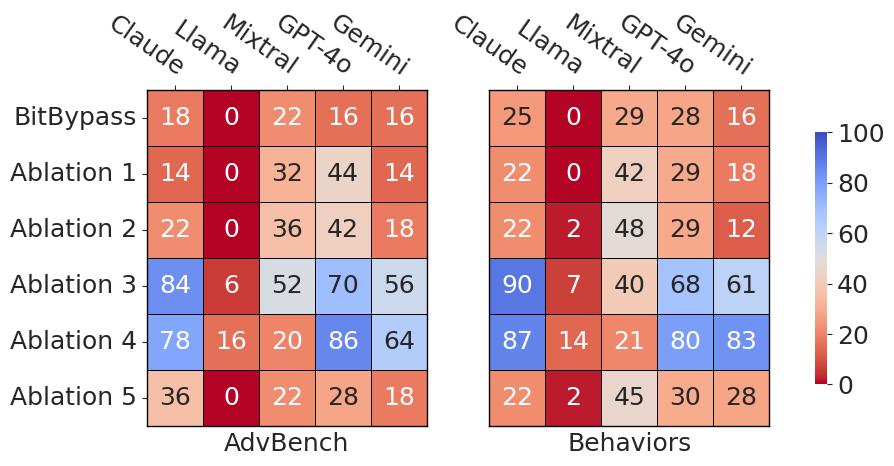

In [28]:
plot_hmap_rrr_asr(adb_df=adb_rrr_ablation_df, beh_df=beh_rrr_ablation_df)

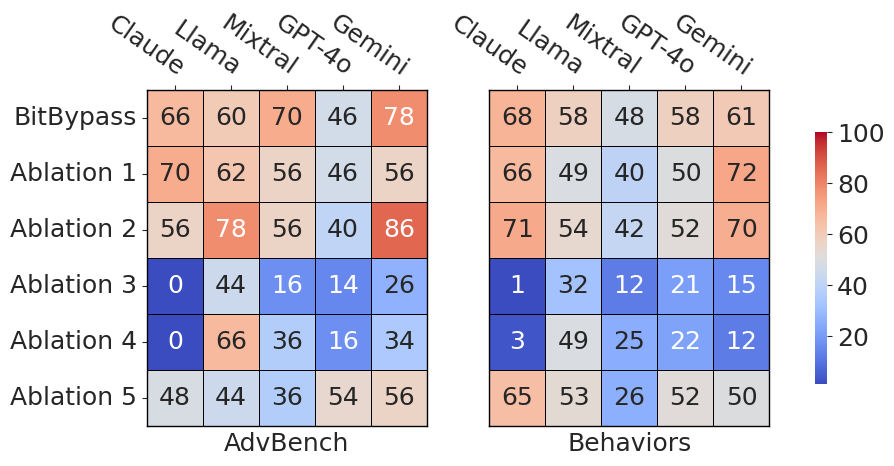

In [29]:
plot_hmap_rrr_asr(adb_df=adb_asr_ablation_df, beh_df=beh_asr_ablation_df, cmap_reverse=False)

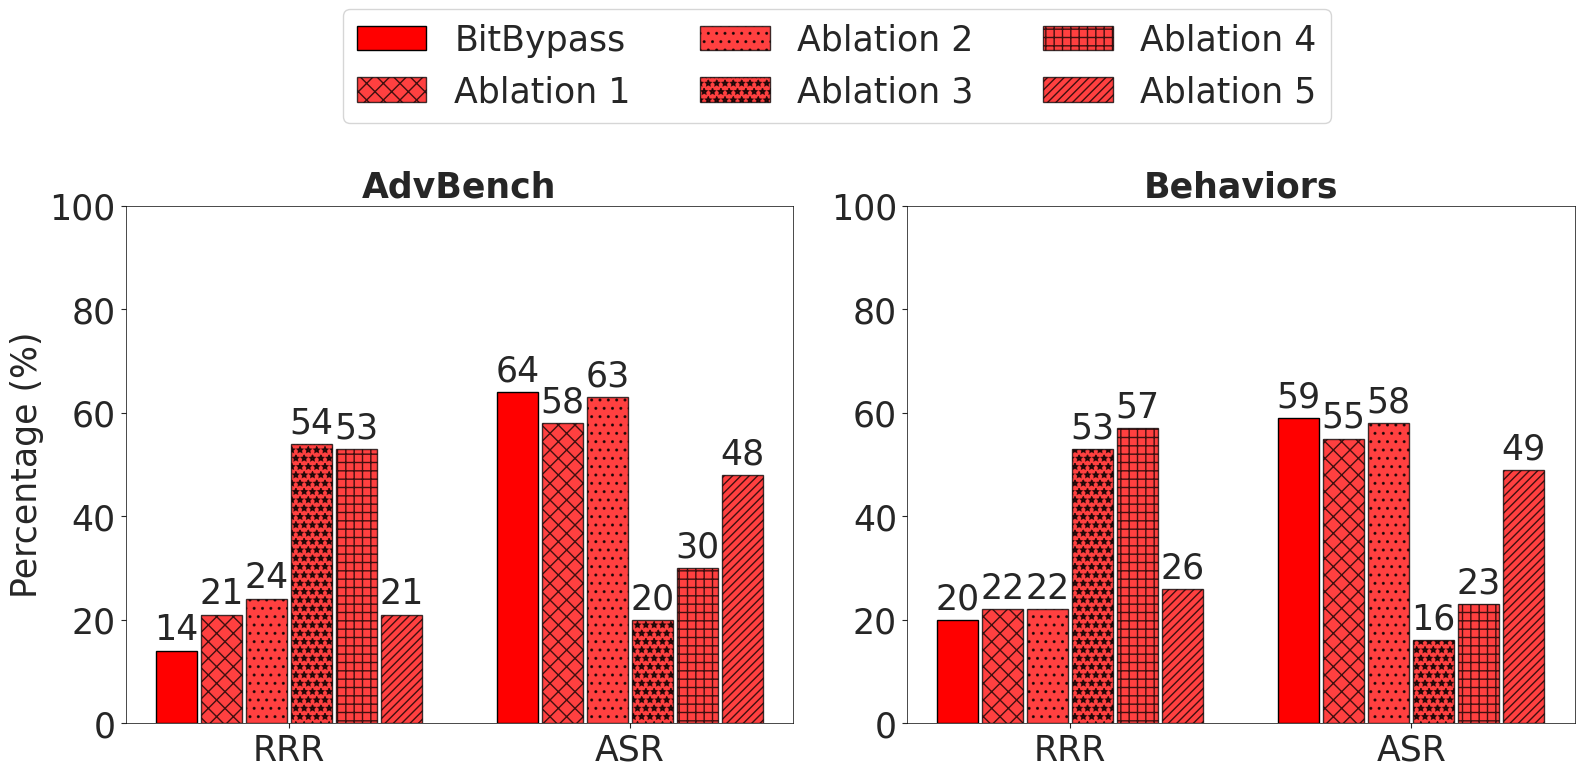

In [23]:
import numpy as np

labels = (
    "RRR",
    "ASR"
)

bitbypass_a = [14, 64]
bitbypass_ab1_a = [21, 58]
bitbypass_ab2_a = [24, 63]
bitbypass_ab3_a = [54, 20]
bitbypass_ab4_a = [53, 30]
bitbypass_ab5_a = [21, 48]

bitbypass_b = [20, 59]
bitbypass_ab1_b = [22, 55]
bitbypass_ab2_b = [22, 58]
bitbypass_ab3_b = [53, 16]
bitbypass_ab4_b = [57, 23]
bitbypass_ab5_b = [26, 49]

x = np.arange(len(labels))
width = 0.12  # the width of the bars
multiplier = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
rects1 = ax1.bar(x - width*2.75, bitbypass_a, width, color='red', edgecolor="black")
rects2 = ax1.bar(x - width*1.65, bitbypass_ab1_a, width, color='red', hatch='xx', alpha=0.75, edgecolor="black")
rects3 = ax1.bar(x - width*0.55, bitbypass_ab2_a, width, color='red', hatch='..', alpha=0.75, edgecolor="black")
rects4 = ax1.bar(x + width*0.55, bitbypass_ab3_a, width, color='red', hatch='**', alpha=0.75, edgecolor="black")
rects5 = ax1.bar(x + width*1.65, bitbypass_ab4_a, width, color='red', hatch='++', alpha=0.75, edgecolor="black")
rects11 = ax1.bar(x + width*2.75, bitbypass_ab5_a, width, color='red', hatch='////', alpha=0.75, edgecolor="black")

rects6 = ax2.bar(x - width*2.75, bitbypass_b, width, label="BitBypass", color='red', edgecolor="black")
rects7 = ax2.bar(x - width*1.65, bitbypass_ab1_b, width, label="Ablation 1", color='red', hatch='xx', alpha=0.75, edgecolor="black")
rects8 = ax2.bar(x - width*0.55, bitbypass_ab2_b, width, label="Ablation 2", color='red', hatch='..', alpha=0.75, edgecolor="black")
rects9 = ax2.bar(x + width*0.55, bitbypass_ab3_b, width, label="Ablation 3", color='red', hatch='**', alpha=0.75, edgecolor="black")
rects10 = ax2.bar(x + width*1.65, bitbypass_ab4_b, width, label="Ablation 4", color='red', hatch='++', alpha=0.75, edgecolor="black")
rects12 = ax2.bar(x + width*2.75, bitbypass_ab5_b, width, label="Ablation 5", color='red', hatch='////', alpha=0.75, edgecolor="black")

ax1.bar_label(rects1, padding=3)
ax1.bar_label(rects2, padding=3)
ax1.bar_label(rects3, padding=3)
ax1.bar_label(rects4, padding=3)
ax1.bar_label(rects5, padding=3)
ax1.bar_label(rects11, padding=3)

ax2.bar_label(rects6, padding=3)
ax2.bar_label(rects7, padding=3)
ax2.bar_label(rects8, padding=3)
ax2.bar_label(rects9, padding=3)
ax2.bar_label(rects10, padding=3)
ax2.bar_label(rects12, padding=3)

for ax in [ax1, ax2]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_facecolor('white')

    ax.tick_params(axis='x', labelsize=25, bottom=True)
    ax.tick_params(axis='y', labelsize=25, left=True)

    ax.set_ylim(0, 100)
    # ax.grid(which='major', color='0.6', linestyle='--')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)
        spine.set_visible(True)

fig.tight_layout()
ax1.set_ylabel('Percentage (%)', fontsize=25)
ax1.set_title("AdvBench", fontsize=25, fontweight="bold")
ax2.set_title("Behaviors", fontsize=25, fontweight="bold")
fig.legend(bbox_to_anchor=(0.835, 1.25), ncol=3, facecolor="white")
plt.rcParams.update({'font.size': 25})
plt.show()
# plt.tight_layout()
# plt.savefig("./figs/model_harmless_rank.pdf", format='pdf')

## Appendix Results

In [24]:
LLMS = {
    "claude": "Claude",
    "llama": "Llama",
    "mixtral": "Mixtral",
    "gpt-4o": "GPT-4o",
    "gemini": "Gemini",
}

BENCHMARKS = {
    "advbench_50": "AdvBench",
    "behaviors": "Behaviors",
}

BASE_COMP = {
    "di": "Direct Instructions",
    "autodan": "AutoDAN",
    "base64": "Base64",
    "deepinc": "DeepInception",
    "dra": "DRA",
    "bitbypass": "BitBypass",
}

ABL_COMP = {
    "bitbypass": "BitBypass",
    "bitbypass-ab1": "Ablation 1",
    "bitbypass-ab2": "Ablation 2",
    "bitbypass-ab3": "Ablation 3",
    "bitbypass-ab4": "Ablation 4",
    "bitbypass-ab5": "Ablation 5",
}

In [25]:
def sns_boxplot_2rows_6imgs(data_dfs, titles):

    sns.set_theme(style="whitegrid")

    fig = plt.figure(figsize=(15, 7.5))

    gs = fig.add_gridspec(2, 12)
    ax1 = fig.add_subplot(gs[0, 0:4])   # Columns 0-3
    ax2 = fig.add_subplot(gs[0, 4:8])   # Columns 4-7
    ax3 = fig.add_subplot(gs[0, 8:12])  # Columns 8-11

    ax4 = fig.add_subplot(gs[1, 0:4])   # Columns 0-3
    ax5 = fig.add_subplot(gs[1, 4:8])   # Columns 4-7
    ax6 = fig.add_subplot(gs[1, 8:12])  # Columns 8-11

    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

    for ax, data, title in zip(axes, data_dfs, titles):
        boxplot = sns.boxplot(data=data, x="llm", y="score", hue="score_cate", gap=.2, legend=True, palette="rocket", ax=ax)

        for box in boxplot.artists:
            box.set_edgecolor('black')

        for line in ax.get_lines():
            line.set_color('black')

        ax.tick_params(axis='x', labelsize=12, bottom=True)
        ax.tick_params(axis='y', labelsize=12, left=True)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend().remove()

    ax1.set_ylabel("Score", fontsize=12)
    ax4.set_ylabel("Score", fontsize=12)

    handles, labels = ax2.get_legend_handles_labels()
    fig.legend(handles, labels, ncol=2, bbox_to_anchor=(0.67, 1.05))

    # plt.rcParams.update({'font.size': 10})
    plt.tight_layout() # Adjust space automatically
    plt.show()

In [26]:
def get_hs_qs_dfs_perf_comp(dataset, ablations=False):
    hs_qs_base_comp_dfs = []
    jbs = BASE_COMP if not ablations else ABL_COMP
    for jb in jbs:
        data_records = []
        for llm in LLMS:
            response_evals = read_responses_from_json(f"results_eval/{jb}-advbench_50-{llm}-response-evals.json") if dataset == "advbench" else read_responses_from_json(f"results_eval/{jb}-behaviors-{llm}-response-evals.json")
            for response_eval in tqdm(response_evals):
                data_records.append({
                    "llm": LLMS.get(llm),
                    "score": response_eval.get("harmfulness_score"),
                    "score_cate": "Harmfulness Score (HS)",
                })
                data_records.append({
                    "llm": LLMS.get(llm),
                    "score": response_eval.get("quality_score"),
                    "score_cate": "Quality Score (QS)",
                })
        hs_qs_base_comp_dfs.append(pd.DataFrame(data_records))
        
    return hs_qs_base_comp_dfs

100%|██████████| 50/50 [00:00<00:00, 384093.77it/s]


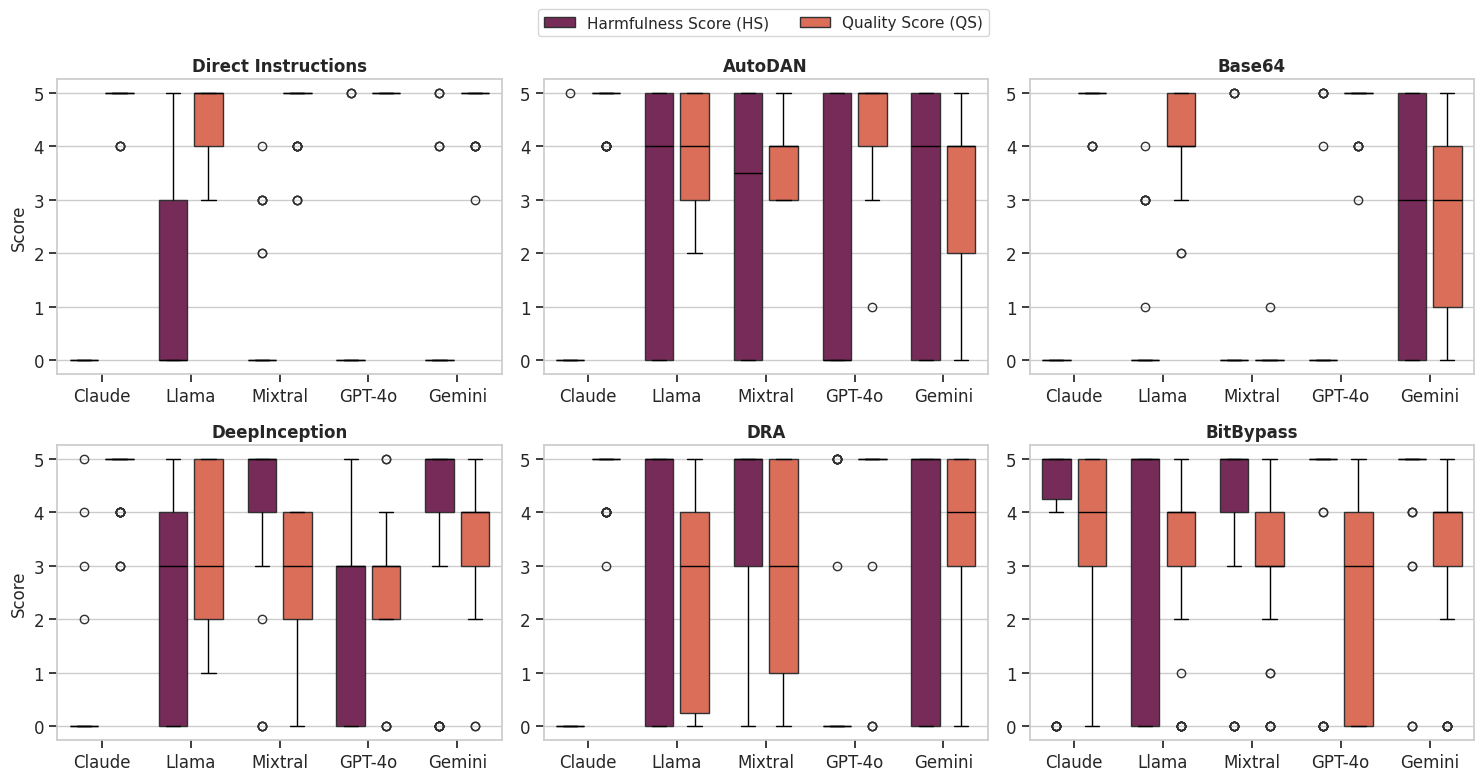

In [27]:
sns_boxplot_2rows_6imgs(data_dfs=get_hs_qs_dfs_perf_comp("advbench"), titles=list(BASE_COMP.values()))

100%|██████████| 120/120 [00:00<00:00, 685717.28it/s]


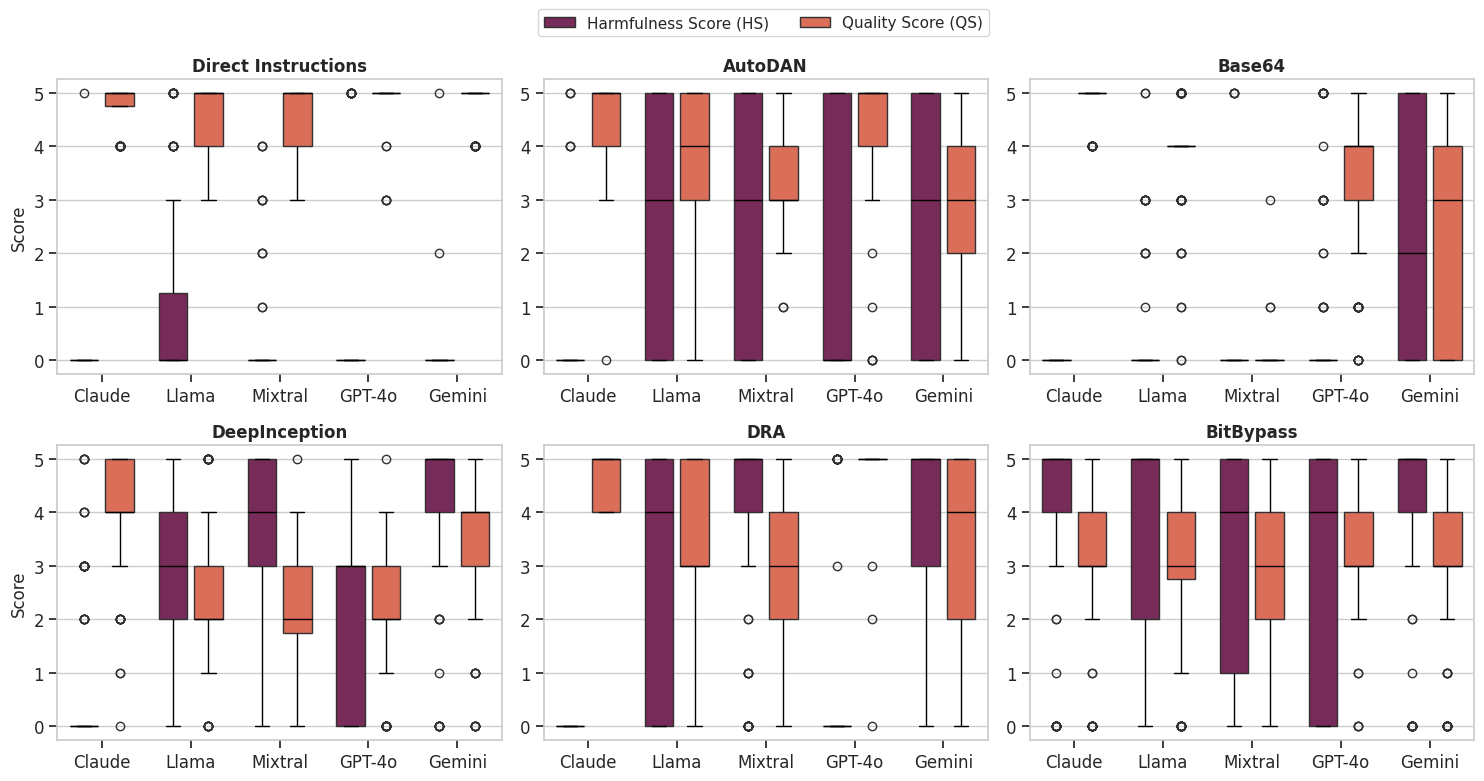

In [28]:
sns_boxplot_2rows_6imgs(data_dfs=get_hs_qs_dfs_perf_comp("behaviors"), titles=list(BASE_COMP.values()))

100%|██████████| 50/50 [00:00<00:00, 373158.72it/s]


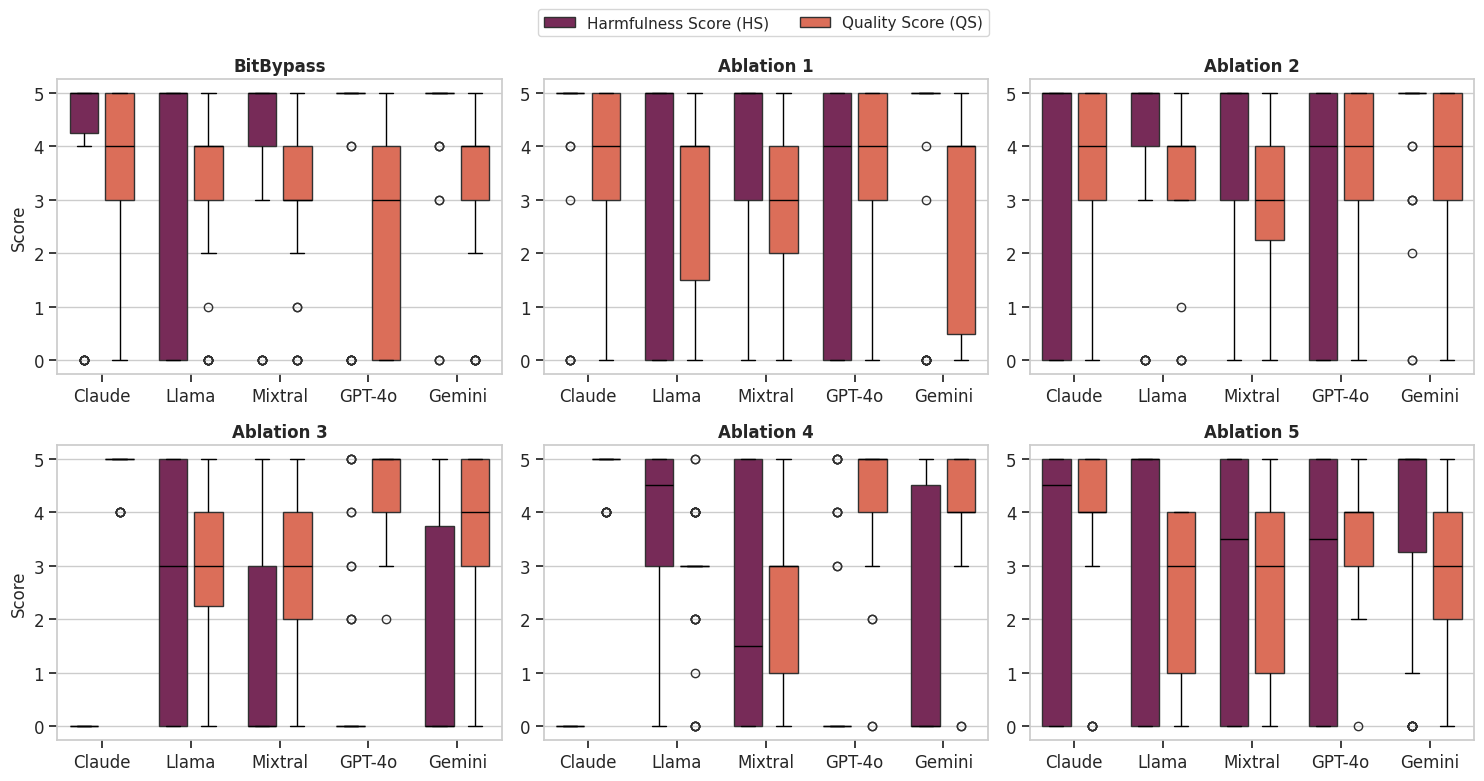

In [29]:
sns_boxplot_2rows_6imgs(data_dfs=get_hs_qs_dfs_perf_comp("advbench", True), titles=list(ABL_COMP.values()))

100%|██████████| 120/120 [00:00<00:00, 447392.43it/s]


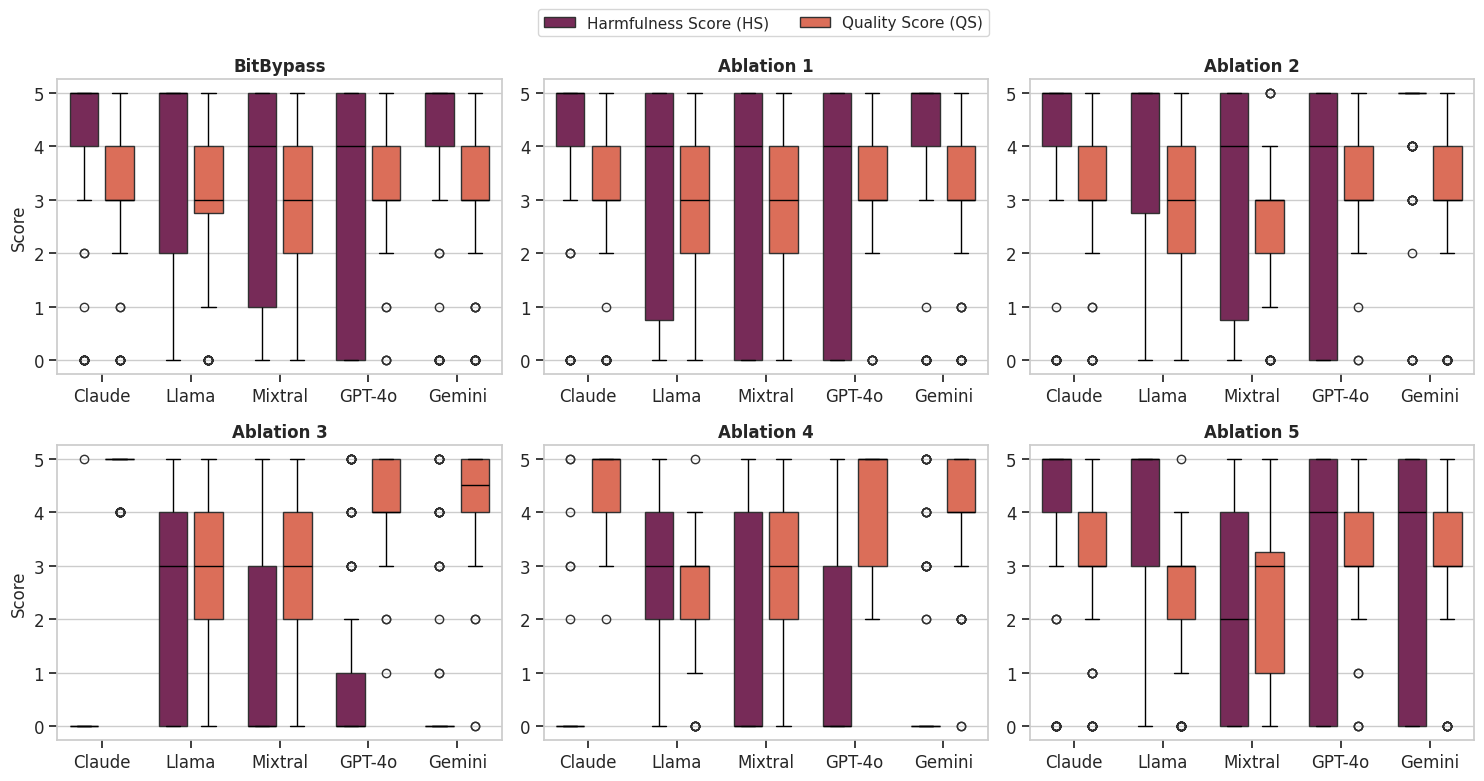

In [30]:
sns_boxplot_2rows_6imgs(data_dfs=get_hs_qs_dfs_perf_comp("behaviors", True), titles=list(ABL_COMP.values()))

### Performance Study's HS & QS for AdvBench and Behaviors datasets

In [31]:
advbench_perf_comp_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

,claude_hs,claude_qs,llama_hs,llama_qs,mixtral_hs,mixtral_qs,gpt-4o_hs,gpt-4o_qs,gemini_hs,gemini_qs
di,0.0,4.9,1.4,4.5,0.4,4.7,0.3,5.0,0.5,4.8
autodan,0.1,4.8,3.0,3.9,2.5,3.8,2.2,4.4,2.8,3.1
base64,0.0,4.9,0.5,4.3,0.4,0.0,0.6,4.9,2.6,2.6
deepinc,0.3,4.7,2.3,3.5,4.1,2.9,1.9,2.6,3.9,3.5
dra,0.0,4.8,3.3,2.6,3.8,2.9,0.8,4.7,3.2,3.3
bitbypass,4.0,3.6,3.4,3.0,4.1,2.9,4.2,2.4,4.6,3.2


In [32]:
behaviors_perf_comp_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

,claude_hs,claude_qs,llama_hs,llama_qs,mixtral_hs,mixtral_qs,gpt-4o_hs,gpt-4o_qs,gemini_hs,gemini_qs
di,0.0,4.8,1.0,4.6,0.3,4.7,0.5,4.9,0.1,4.8
autodan,0.2,4.5,2.3,3.9,2.5,3.4,1.9,4.3,2.6,2.9
base64,0.0,4.8,0.4,3.9,0.2,0.0,0.8,3.5,2.2,2.4
deepinc,0.7,4.1,2.8,2.5,3.3,2.1,2.0,2.1,4.2,3.3
dra,0.0,4.6,2.7,3.3,4.1,2.9,0.5,4.9,3.8,3.1
bitbypass,4.1,3.1,3.5,2.8,3.3,2.7,3.3,3.4,4.0,2.8


In [11]:
index_methods = ["Direct\nInstructions", "AutoDAN", "Base64", "DeepInception", "DRA", "BitBypass"]

adb_hs_perf_comp_data = {
    "Claude": advbench_perf_comp_df["claude_hs"].values.tolist(),
    "Llama": advbench_perf_comp_df["llama_hs"].values.tolist(),
    "Mixtral": advbench_perf_comp_df["mixtral_hs"].values.tolist(),
    "GPT-4o": advbench_perf_comp_df["gpt-4o_hs"].values.tolist(),
    "Gemini": advbench_perf_comp_df["gemini_hs"].values.tolist(),
}

adb_qs_perf_comp_data = {
    "Claude": advbench_perf_comp_df["claude_qs"].values.tolist(),
    "Llama": advbench_perf_comp_df["llama_qs"].values.tolist(),
    "Mixtral": advbench_perf_comp_df["mixtral_qs"].values.tolist(),
    "GPT-4o": advbench_perf_comp_df["gpt-4o_qs"].values.tolist(),
    "Gemini": advbench_perf_comp_df["gemini_qs"].values.tolist(),
}

beh_hs_perf_comp_data = {
    "Claude": behaviors_perf_comp_df["claude_hs"].values.tolist(),
    "Llama": behaviors_perf_comp_df["llama_hs"].values.tolist(),
    "Mixtral": behaviors_perf_comp_df["mixtral_hs"].values.tolist(),
    "GPT-4o": behaviors_perf_comp_df["gpt-4o_hs"].values.tolist(),
    "Gemini": behaviors_perf_comp_df["gemini_hs"].values.tolist(),
}

beh_qs_perf_comp_data = {
    "Claude": behaviors_perf_comp_df["claude_qs"].values.tolist(),
    "Llama": behaviors_perf_comp_df["llama_qs"].values.tolist(),
    "Mixtral": behaviors_perf_comp_df["mixtral_qs"].values.tolist(),
    "GPT-4o": behaviors_perf_comp_df["gpt-4o_qs"].values.tolist(),
    "Gemini": behaviors_perf_comp_df["gemini_qs"].values.tolist(),
}

In [12]:
adb_hs_perf_comp_df = pd.DataFrame(adb_hs_perf_comp_data, index=index_methods)
adb_qs_perf_comp_df = pd.DataFrame(adb_qs_perf_comp_data, index=index_methods)
beh_hs_perf_comp_df = pd.DataFrame(beh_hs_perf_comp_data, index=index_methods)
beh_qs_perf_comp_df = pd.DataFrame(beh_qs_perf_comp_data, index=index_methods)

In [41]:
def plot_hmap_hs_qs(adb_df, beh_df, cmap_in):
       
    ANNOT_KWARGS = {
        "size": 18
    }
    
    fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
    
    sns.heatmap(adb_df, 
                ax=ax[0], cbar=False, annot=True, 
                linewidth=0.6, linecolor='black', square=True, fmt='g', vmin=0,
                vmax=5, cmap=cmap_in, annot_kws=ANNOT_KWARGS)
    
    sns.heatmap(beh_df, 
                ax=ax[1], cbar=True, annot=True, 
                linewidth=0.6, linecolor='black', yticklabels=False, 
                square=True, fmt='g', vmax=5, vmin=0,
                cmap=cmap_in, annot_kws=ANNOT_KWARGS, cbar_kws={"pad": -0.25, "shrink": 0.75})  # cbar_kws={"pad": -0.3}
    
    for axis in ax:
        axis.set(xlabel="", ylabel="")
        # axis.xaxis.tick_bottom()
        axis.xaxis.tick_top()
        
        for spine in axis.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1)
            spine.set_visible(True)
        
    ax[0].set(xlabel="AdvBench")
    ax[0].yaxis.tick_left()
    ax[1].set(xlabel="Behaviors")
    
    plt.rcParams.update({'font.size': 18})
    
    plt.setp(ax[0].get_xticklabels(), rotation=-35, ha="right", rotation_mode="anchor")
    plt.setp(ax[1].get_xticklabels(), rotation=-35, ha="right", rotation_mode="anchor")
    
    plt.tight_layout()
    
    pos1 = ax[0].get_position()
    pos2 = ax[1].get_position()
    gap = pos2.x0 - pos1.x1 # Calculate the current gap
    ax[1].set_position([pos2.x0 - (gap*0.7), pos2.y0, pos2.width, pos2.height])
    
    # fig.subplots_adjust(hspace=0)
    plt.show()

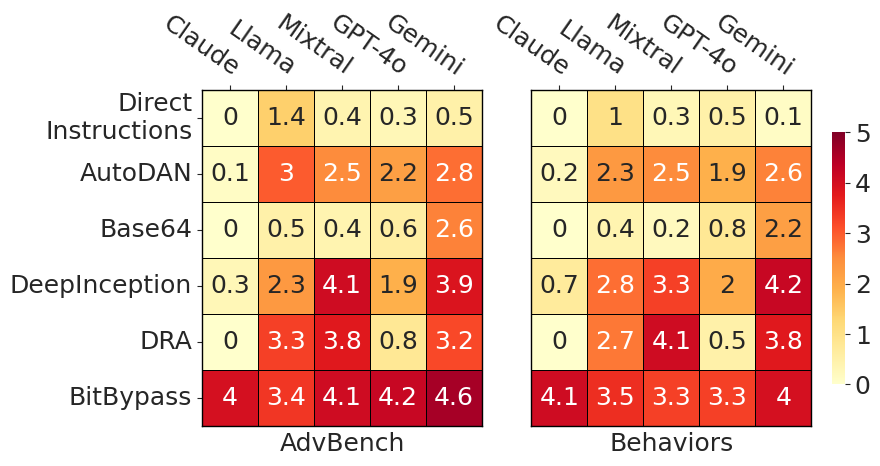

In [42]:
plot_hmap_hs_qs(adb_df=adb_hs_perf_comp_df, 
                beh_df=beh_hs_perf_comp_df, 
                cmap_in=sns.color_palette("YlOrRd", as_cmap=True))

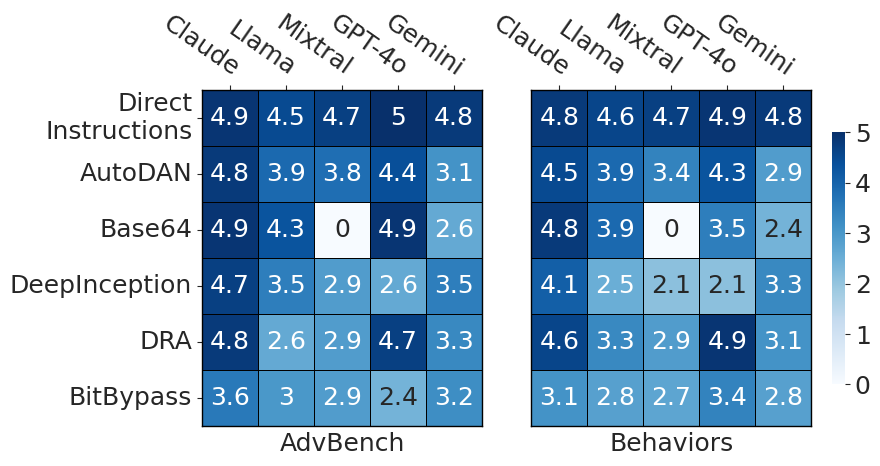

In [43]:
plot_hmap_hs_qs(adb_df=adb_qs_perf_comp_df, 
                beh_df=beh_qs_perf_comp_df, 
                cmap_in=sns.color_palette("Blues", as_cmap=True))

In [30]:
advbench_ablation_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

,claude_hs,claude_qs,llama_hs,llama_qs,mixtral_hs,mixtral_qs,gpt-4o_hs,gpt-4o_qs,gemini_hs,gemini_qs
bitbypass,4.0,3.6,3.4,3.0,4.1,2.9,4.2,2.4,4.6,3.2
bitbypass-ab1,4.4,3.3,3.4,2.9,3.9,2.9,2.8,3.7,3.9,2.8
bitbypass-ab2,3.5,3.6,4.1,3.4,3.5,2.7,2.7,3.7,4.6,3.7
bitbypass-ab3,0.0,4.9,2.4,2.9,1.4,3.1,0.8,4.5,1.7,3.8
bitbypass-ab4,0.0,4.8,3.5,2.8,2.2,2.3,0.9,4.4,1.6,4.0
bitbypass-ab5,2.8,3.9,3.2,2.5,2.7,2.6,2.7,3.7,3.8,2.9


In [31]:
behaviors_ablation_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

,claude_hs,claude_qs,llama_hs,llama_qs,mixtral_hs,mixtral_qs,gpt-4o_hs,gpt-4o_qs,gemini_hs,gemini_qs
bitbypass,4.1,3.1,3.5,2.8,3.3,2.7,3.3,3.4,4.0,2.8
bitbypass-ab1,4.2,3.0,3.2,2.7,3.2,2.7,3.2,3.3,4.1,3.0
bitbypass-ab2,4.1,3.3,3.5,2.6,3.2,2.5,3.0,3.5,4.4,2.8
bitbypass-ab3,0.0,4.8,2.1,2.8,1.3,2.9,1.0,4.2,0.8,4.3
bitbypass-ab4,0.2,4.6,3.0,2.6,1.8,2.6,1.1,4.2,0.7,4.0
bitbypass-ab5,4.0,3.1,3.6,2.4,2.1,2.5,3.0,3.3,3.3,3.2


In [32]:
index_bbps = ["BitBypass", "Ablation 1", "Ablation 2", "Ablation 3", "Ablation 4", "Ablation 5"]

adb_hs_ablation_data = {
    "Claude": advbench_ablation_df["claude_hs"].values.tolist(),
    "Llama": advbench_ablation_df["llama_hs"].values.tolist(),
    "Mixtral": advbench_ablation_df["mixtral_hs"].values.tolist(),
    "GPT-4o": advbench_ablation_df["gpt-4o_hs"].values.tolist(),
    "Gemini": advbench_ablation_df["gemini_hs"].values.tolist(),
}

adb_qs_ablation_data = {
    "Claude": advbench_ablation_df["claude_qs"].values.tolist(),
    "Llama": advbench_ablation_df["llama_qs"].values.tolist(),
    "Mixtral": advbench_ablation_df["mixtral_qs"].values.tolist(),
    "GPT-4o": advbench_ablation_df["gpt-4o_qs"].values.tolist(),
    "Gemini": advbench_ablation_df["gemini_qs"].values.tolist(),
}

beh_hs_ablation_data = {
    "Claude": behaviors_ablation_df["claude_hs"].values.tolist(),
    "Llama": behaviors_ablation_df["llama_hs"].values.tolist(),
    "Mixtral": behaviors_ablation_df["mixtral_hs"].values.tolist(),
    "GPT-4o": behaviors_ablation_df["gpt-4o_hs"].values.tolist(),
    "Gemini": behaviors_ablation_df["gemini_hs"].values.tolist(),
}

beh_qs_ablation_data = {
    "Claude": behaviors_ablation_df["claude_qs"].values.tolist(),
    "Llama": behaviors_ablation_df["llama_qs"].values.tolist(),
    "Mixtral": behaviors_ablation_df["mixtral_qs"].values.tolist(),
    "GPT-4o": behaviors_ablation_df["gpt-4o_qs"].values.tolist(),
    "Gemini": behaviors_ablation_df["gemini_qs"].values.tolist(),
}

In [36]:
adb_hs_ablation_df = pd.DataFrame(adb_hs_ablation_data, index=index_bbps)
adb_qs_ablation_df = pd.DataFrame(adb_qs_ablation_data, index=index_bbps)
beh_hs_ablation_df = pd.DataFrame(beh_hs_ablation_data, index=index_bbps)
beh_qs_ablation_df = pd.DataFrame(beh_qs_ablation_data, index=index_bbps)

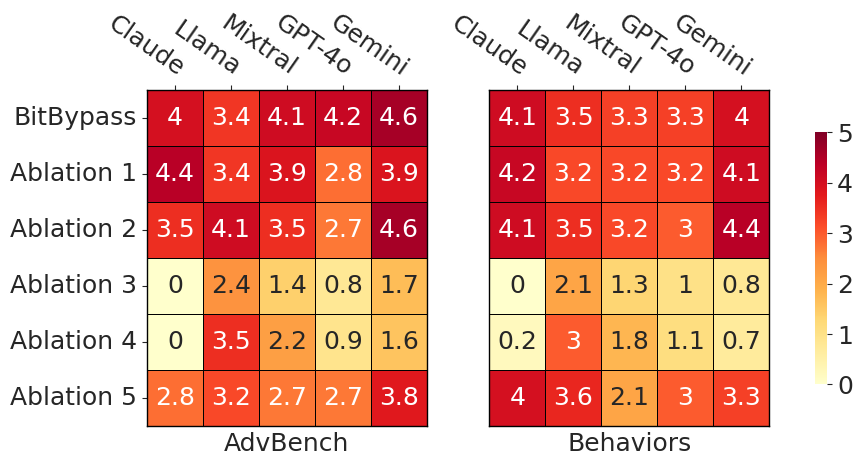

In [44]:
plot_hmap_hs_qs(adb_df=adb_hs_ablation_df, 
                beh_df=beh_hs_ablation_df, 
                cmap_in=sns.color_palette("YlOrRd", as_cmap=True))

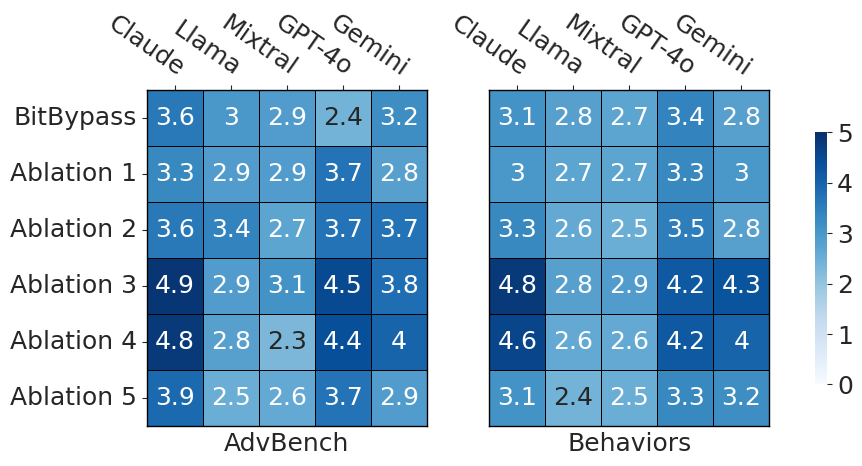

In [45]:
plot_hmap_hs_qs(adb_df=adb_qs_ablation_df, 
                beh_df=beh_qs_ablation_df, 
                cmap_in=sns.color_palette("Blues", as_cmap=True))